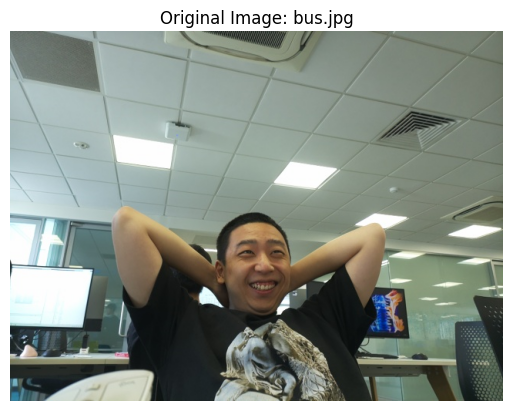

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import backend.processing_logic as processing_logic
from ultralytics import YOLO

# 加载测试图像
# image_path = 'backend/data/bus.jpg'
image_path = 'backend/data/captured_image.jpg'
image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

# 加载 YOLO 模型
yolo_model = YOLO('backend/resource/models/yolov8n-seg.pt')

# 显示原始图像
plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
plt.title('Original Image: bus.jpg')
plt.axis('off')
plt.show()

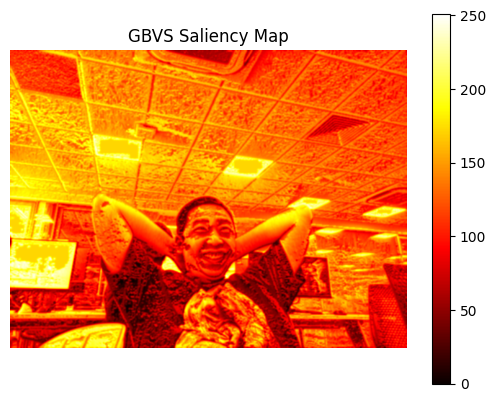

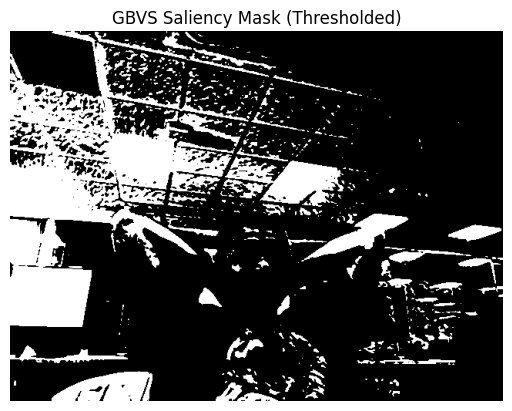

In [15]:
def compute_gbvs_saliency(image_bgr, blur_size=3, weight_color=1.0, weight_intensity=1.0, weight_orientation=1.0):
    """
    Simplified GBVS implementation using OpenCV and NumPy.
    Args:
        image_bgr: Input BGR image (NumPy array)
        blur_size: Gaussian blur kernel size
        weight_color: Weight for color channel
        weight_intensity: Weight for intensity channel
        weight_orientation: Weight for orientation channel
    Returns:
        saliency_map: Normalized saliency map (0-1)
    """
    # Convert to RGB and grayscale
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    
    # Feature channels
    # 1. Color (R, G, B channels)
    r, g, b = cv2.split(image_rgb)
    color_maps = []
    for channel in (r, g, b):
        channel = cv2.GaussianBlur(channel, (blur_size, blur_size), 0)
        color_maps.append(cv2.normalize(channel.astype(float), None, 0, 1, cv2.NORM_MINMAX))
    
    # 2. Intensity
    intensity = cv2.GaussianBlur(image_gray, (blur_size, blur_size), 0)
    intensity_map = cv2.normalize(intensity.astype(float), None, 0, 1, cv2.NORM_MINMAX)
    
    # 3. Orientation (using Sobel filters)
    orient_maps = []
    for angle in [0, 45, 90, 135]:
        sobel_x = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=3)
        orient = cv2.phase(sobel_x, sobel_y, angleInDegrees=True)
        orient = cv2.GaussianBlur(orient, (blur_size, blur_size), 0)
        orient_maps.append(cv2.normalize(orient, None, 0, 1, cv2.NORM_MINMAX))
    
    # Combine feature maps (weighted sum)
    saliency_map = np.zeros_like(intensity_map)
    for cmap in color_maps:
        saliency_map += weight_color * cmap / len(color_maps)
    saliency_map += weight_intensity * intensity_map
    for omap in orient_maps:
        saliency_map += weight_orientation * omap / len(orient_maps)
    
    # Normalize and smooth
    saliency_map = cv2.normalize(saliency_map, None, 0, 1, cv2.NORM_MINMAX)
    saliency_map = cv2.GaussianBlur(saliency_map, (blur_size, blur_size), 0)
    
    return saliency_map

# 测试 GBVS 显著性分析
saliency_map = compute_gbvs_saliency(image_bgr)
saliency_map_uint8 = (saliency_map * 255).astype(np.uint8)

# 显示显著性图
plt.imshow(saliency_map_uint8, cmap='hot')
plt.title('GBVS Saliency Map')
plt.axis('off')
plt.colorbar()
plt.show()

# 阈值化显著性掩码
threshold = 0.6
saliency_mask = (saliency_map > threshold).astype(np.uint8) * 255
plt.imshow(saliency_mask, cmap='gray')
plt.title('GBVS Saliency Mask (Thresholded)')
plt.axis('off')
plt.show()


0: 480x640 2 persons, 133.6ms
Speed: 6.0ms preprocess, 133.6ms inference, 5.0ms postprocess per image at shape (1, 3, 480, 640)
Detections with GBVS Saliency:
{
  "class": "person",
  "group": "person",
  "confidence": 0.3931584060192108,
  "bbox": [
    359,
    241,
    501,
    478
  ],
  "dominant_color": [
    8.694364640881265,
    19.28453038674309,
    39.54397790056679
  ],
  "color_name": "red",
  "mask_area": 0.058919270833333336,
  "sub_class": "unknown",
  "sub_confidence": 0.0,
  "saliency_score": 0.40457926210802714
}
{
  "class": "person",
  "group": "person",
  "confidence": 0.2654547691345215,
  "bbox": [
    258,
    233,
    421,
    479
  ],
  "dominant_color": [
    26.298901570713046,
    14.177466098966871,
    47.89906615621206
  ],
  "color_name": "orange",
  "mask_area": 0.09097981770833333,
  "sub_class": "unknown",
  "sub_confidence": 0.0,
  "saliency_score": 0.40013093264775024
}


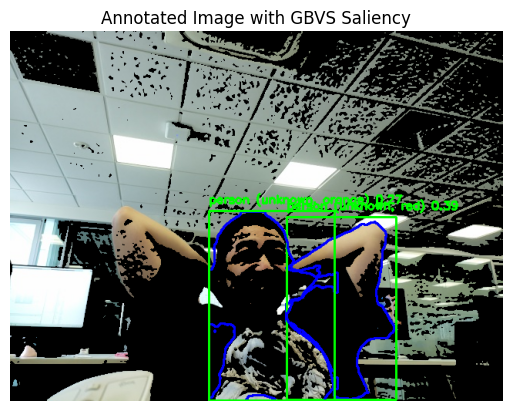

In [8]:
import json

# 修改 detect_objects_yolo 以使用 GBVS 显著性掩码
def detect_objects_with_gbvs(image_bgr, yolo_model, secondary_model=None, color_space='HSV', saliency_threshold=0.5):
    """
    Detect objects using YOLO with GBVS saliency preprocessing.
    Args:
        image_bgr: Input BGR image
        yolo_model: Loaded YOLO model
        secondary_model: Secondary classification model
        color_space: 'HSV' or 'HSL'
        saliency_threshold: Threshold for saliency mask
    Returns:
        detections: List of detection results with saliency scores
        annotated_image: Image with bounding boxes and labels
    """
    # 生成 GBVS 显著性图
    saliency_map = compute_gbvs_saliency(image_bgr)
    saliency_mask = (saliency_map > saliency_threshold).astype(np.uint8)
    
    # 对显著区域运行 YOLO
    masked_image = image_bgr * saliency_mask[..., None]
    detections, annotated_image = processing_logic.detect_objects_yolo(
        masked_image, yolo_model, secondary_model, color_space
    )
    
    # 添加显著性得分
    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        roi_saliency = saliency_map[y1:y2, x1:x2].mean()
        det['saliency_score'] = float(roi_saliency)
    
    return detections, annotated_image

# 测试 GBVS 增强的检测
detections, annotated_image = detect_objects_with_gbvs(image_bgr, yolo_model, color_space='HSV')
print("Detections with GBVS Saliency:")
for det in detections:
    print(json.dumps(det, indent=2))

# 显示带注释的图像
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title('Annotated Image with GBVS Saliency')
plt.axis('off')
plt.show()